In [2]:
# import liberays
# veri seti yükleme
# metin temizleme
# metin tokenization
# word2vec modellem
# fasttext modelleme
# görselleştirme pca


In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import re
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

! pip install gensim
from  gensim.models import Word2Vec, FastText
from gensim.utils import simple_preprocess


In [31]:
df=pd.read_csv("C:\\Users\\kadir\\OneDrive\\Masaüstü\\llm\\bag_of_words\\IMBD.csv\\IMBD.csv")
documents=df["description"]

In [32]:
!pip install nltk
import nltk
from nltk.corpus import stopwords
nltk.download("stopwords")
stop_words=set(stopwords.words("english"))

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\kadir\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [33]:
def clean_text(text):
    text=text.lower()
    text=re.sub(r"\s+", " ", text).strip()
    text=re.sub(r"\d+", "", text)

    text="".join([word for word in text.split() if word not in stop_words])
    return text

tokenized_docs=[simple_preprocess(clean_text(doc)) for doc in documents]


In [34]:
print(tokenized_docs)

[['middle', 'artsrivalsagain'], [], [], [], ['everythinglose'], ['dream'], ['so', 'brightgrandson'], ['sfuture'], ['threetwenty'], [], ['mother'], ['high', 'cross'], [], [], ['sbullies'], [], ['sdescent'], [], [], ['live', 'swinxclub'], [], [], [], ['insaneasylum', 'witchcoven', 'freakshowcircus', 'hauntedhotel', 'cult', 'apocalypse'], [], ['swashington'], ['something', 'year'], ['scrappy', 'feisty'], [], [], [], ['cia'], [], ['onenewyorkcity', 'sbestlawyers'], ['andraid'], ['geraltrivia'], ['newfbiprofiler', 'elizabethkeen'], [], ['cityangels'], ['grownapart'], ['uhtred'], [], ['italy', 'breakup', 'booked'], ['high'], ['sthprecinct'], ['hundredscash', 'sgames', 'inside', 'billion', 'wonprizestake'], ['connecticut'], [], [], ['schildhood'], [], [], ['keyhouse', 'sdeath'], ['hard', 'working', 'blue', 'witted', 'year', 'olddaughter'], [], [], [], [], ['lives', 'loves', 'mysticfalls', 'virginia'], [], [], ['northdakota'], [], ['gigolo', 'falllove'], [], [], ['newfriends', 'navigatinglove'

In [35]:
Word2Vec_model=Word2Vec(sentences=tokenized_docs, vector_size=100, window=5, min_count=2, workers=4, sg=0)
FastText_model=FastText(sentences=tokenized_docs, vector_size=100, window=5, min_count=2, workers=4, sg=0)

In [36]:
word=list(Word2Vec_model.wv.index_to_key)[:500]
vectors=[Word2Vec_model.wv[word] for word in word]

In [37]:
kmeans=KMeans(n_clusters=2, random_state=42)
kmeans.fit(vectors)
clusters=kmeans.labels_

In [38]:
pca=PCA(n_components=2, random_state=42)
reduced_vectors=pca.fit_transform(vectors)

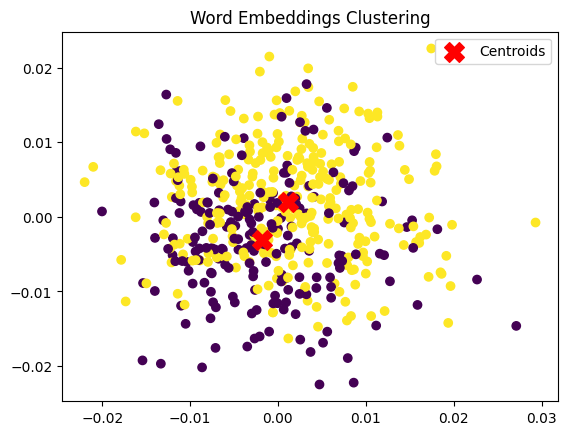

In [39]:
plt.figure()
plt.scatter(reduced_vectors[:, 0], reduced_vectors[:, 1], c=clusters, cmap="viridis")
plt.title("Word Embeddings Clustering")

center=pca.transform(kmeans.cluster_centers_)
plt.scatter(center[:, 0], center[:, 1], c="red", marker="X", s=200, label="Centroids")
plt.legend()